In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

In [3]:
atac = pd.read_csv("data/ImmGenATAC18_AllOCRsInfo.csv")
rna = pd.read_csv("data/mmc2.csv")
refflat = pd.read_csv("data/refFlat.txt", sep="\t", header=None)
refflat.columns = [
    "geneName", "name2", "chrom", "strand", "txStart", "txEnd",
    "cdsStart", "cdsEnd", "exonCount", "exonStarts", "exonEnds"
]


In [4]:
cell_types = [
    "NK.27+11b-.BM", "NK.27+11b+.BM", "NK.27-11b+.BM",
    "NK.27+11b-.Sp", "NK.27+11b+.Sp", "NK.27-11b+.Sp",
    "ILC2.SI", "ILC3.NKp46-CCR6-.SI", "ILC3.NKp46+.SI", "ILC3.CCR6+.SI"
]


In [5]:
rna = rna.rename(columns={"Unnamed: 0": "gene"})
rna_filtered = rna.set_index("gene")[cell_types]

atac = atac[atac[cell_types].notnull().all(axis=1)].copy()
atac["midpoint"] = atac["Summit"]
atac_filtered = atac[["ImmGenATAC1219.peakID", "chrom", "midpoint", "genes.within.100Kb"] + cell_types]


In [6]:
refflat["TSS"] = np.where(refflat["strand"] == "+", refflat["txStart"], refflat["txEnd"])
gene_tss = refflat[["geneName", "chrom", "TSS"]].drop_duplicates()

In [7]:
rows = []
window = 100_000

for i, row in atac_filtered.iterrows():
    peak_id = row["ImmGenATAC1219.peakID"]
    chrom = row["chrom"]
    midpoint = row["midpoint"]
    signal = row[cell_types].values
    if pd.isna(row["genes.within.100Kb"]):
        continue

    genes = [g.strip() for g in str(row["genes.within.100Kb"]).split(";")]
    for gene in genes:
        if gene in rna_filtered.index and gene_tss["geneName"].eq(gene).any():
            gene_row = gene_tss[gene_tss["geneName"] == gene]
            gene_chrom = gene_row["chrom"].values[0]
            tss = gene_row["TSS"].values[0]

            if gene_chrom != chrom:
                continue

            expr = rna_filtered.loc[gene].values
            corr, _ = pearsonr(signal, expr)

            rows.append({
                "ocr_id": peak_id,
                "gene": gene,
                "chrom": chrom,
                "distance": midpoint - tss,
                "abs_distance": abs(midpoint - tss),
                "correlation": corr
            })

all_assoc_df = pd.DataFrame(rows)
print("Associations OCR ↔ gen:", all_assoc_df.shape)

/var/folders/vh/rffjtjt916gdtb214wntxwb80000gn/T/ipykernel_42621/4101964422.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(signal, expr)


Associations OCR ↔ gen: (98593, 6)


In [8]:
# 1) Peek at the first few rows
print(all_assoc_df.head())

# 2) Summary statistics for the correlation values
print(all_assoc_df['correlation'].describe())


                   ocr_id gene chrom  distance  abs_distance  correlation
0  ImmGenATAC1219.peak_40  Rp1  chr1    -90921         90921    -0.071801
1  ImmGenATAC1219.peak_41  Rp1  chr1    -82495         82495    -0.385127
2  ImmGenATAC1219.peak_42  Rp1  chr1    -79777         79777    -0.606339
3  ImmGenATAC1219.peak_43  Rp1  chr1    -76586         76586     0.034226
4  ImmGenATAC1219.peak_44  Rp1  chr1    -63686         63686    -0.280642
count    98592.000000
mean         0.043387
std          0.398625
min         -0.988247
25%         -0.258163
50%          0.007728
75%          0.328815
max          0.999173
Name: correlation, dtype: float64


In [9]:
import numpy as np

# 1) Label effect direction based on the sign of correlation
all_assoc_df['effect_direction'] = np.where(
    all_assoc_df['correlation'] > 0, 'activator',
    np.where(all_assoc_df['correlation'] < 0, 'repressor', 'neutral')
)

# 2) Quick sanity check: count how many of each
print(all_assoc_df['effect_direction'].value_counts())


effect_direction
activator    49990
repressor    48602
neutral          1
Name: count, dtype: int64


In [10]:
#  Merge effect_direction into atac_filtered
merged = atac_filtered.merge(
    all_assoc_df[['ocr_id', 'effect_direction']],
    left_on='ImmGenATAC1219.peakID',
    right_on='ocr_id',
    how='left'
)

#  Drop the now-redundant 'ocr_id' column
merged = merged.drop(columns=['ocr_id'])

# Quick check
print(merged[['ImmGenATAC1219.peakID', 'effect_direction']].head())
print(merged['effect_direction'].isna().sum(), "peaks with no label (should be zero or very small).")
# Label peaks without any gene association
merged['effect_direction'] = merged['effect_direction'].fillna('no_association')

# Check the new distribution
print(merged['effect_direction'].value_counts())



   ImmGenATAC1219.peakID effect_direction
0  ImmGenATAC1219.peak_1              NaN
1  ImmGenATAC1219.peak_2              NaN
2  ImmGenATAC1219.peak_3              NaN
3  ImmGenATAC1219.peak_4              NaN
4  ImmGenATAC1219.peak_5              NaN
414002 peaks with no label (should be zero or very small).
effect_direction
no_association    414002
activator          49990
repressor          48602
neutral                1
Name: count, dtype: int64


In [11]:
# Samples of each ID list
print("ATAC peak IDs (first 5):", atac_filtered['ImmGenATAC1219.peakID'].iloc[:5].tolist())
print("Assoc ocr_ids (first 5):", all_assoc_df['ocr_id'].iloc[:5].tolist())

# How many ATAC peaks have a matching assoc row?
n_match = atac_filtered['ImmGenATAC1219.peakID'].isin(all_assoc_df['ocr_id']).sum()
print(f"{n_match} out of {len(atac_filtered)} ATAC peaks have a matching ocr_id in all_assoc_df")


ATAC peak IDs (first 5): ['ImmGenATAC1219.peak_1', 'ImmGenATAC1219.peak_2', 'ImmGenATAC1219.peak_3', 'ImmGenATAC1219.peak_4', 'ImmGenATAC1219.peak_5']
Assoc ocr_ids (first 5): ['ImmGenATAC1219.peak_40', 'ImmGenATAC1219.peak_41', 'ImmGenATAC1219.peak_42', 'ImmGenATAC1219.peak_43', 'ImmGenATAC1219.peak_44']
98593 out of 512595 ATAC peaks have a matching ocr_id in all_assoc_df


In [12]:
# 1a) Merge into a new DataFrame
atac2 = atac_filtered.merge(
    all_assoc_df[['ocr_id', 'effect_direction']],
    left_on='ImmGenATAC1219.peakID',
    right_on='ocr_id',
    how='left'
).drop(columns=['ocr_id'])

# 1b) Before filling, check how many NaNs
print("Missing before fill:", atac2['effect_direction'].isna().sum())

# 1c) Fill missing with 'no_association'
atac2['effect_direction'] = atac2['effect_direction'].fillna('no_association')

# 1d) After filling, confirm
print("Missing after fill: ", atac2['effect_direction'].isna().sum())
print("\nValue counts:")
print(atac2['effect_direction'].value_counts(dropna=False))


Missing before fill: 414002
Missing after fill:  0

Value counts:
effect_direction
no_association    414002
activator          49990
repressor          48602
neutral                1
Name: count, dtype: int64


In [13]:
# Keep only peaks that have an association
assoc_peaks = atac2[ atac2['effect_direction'] != 'no_association' ].copy()

# Check how many remain
print("Number of associated peaks:", assoc_peaks.shape[0])

# Now repeat clustering & fraction calculation on assoc_peaks:
from sklearn.cluster import KMeans

# 2) Re-cluster (optional—only if you want clusters *within* assoc set)
X_assoc = assoc_peaks[cell_types].values
kmeans = KMeans(n_clusters=4, random_state=42)
assoc_peaks['cluster'] = kmeans.fit_predict(X_assoc)

# 3) Recompute counts & fractions
counts_assoc = (
    assoc_peaks
    .groupby(['cluster','effect_direction'])
    .size()
    .unstack(fill_value=0)
)
counts_assoc['total'] = counts_assoc.sum(axis=1)
counts_assoc['frac_activator'] = counts_assoc['activator'] / counts_assoc['total']
counts_assoc['frac_repressor'] = counts_assoc['repressor'] / counts_assoc['total']

print(counts_assoc[['activator','repressor','frac_activator','frac_repressor']])


Number of associated peaks: 98593
effect_direction  activator  repressor  frac_activator  frac_repressor
cluster                                                               
0                     45224      45347        0.499321        0.500679
1                       108         94        0.532020        0.463054
2                       741        538        0.579359        0.420641
3                      3917       2623        0.598930        0.401070


In [14]:
# 1) Tabulate counts per cluster & effect_direction
counts_filt = (
    assoc_peaks
    .groupby(['cluster','effect_direction'])
    .size()
    .unstack(fill_value=0)
)

# 2) Total associated peaks per cluster
counts_filt['total'] = counts_filt.sum(axis=1)

# 3) Fractions of activator vs. repressor
counts_filt['frac_activator'] = counts_filt['activator'] / counts_filt['total']
counts_filt['frac_repressor'] = counts_filt['repressor'] / counts_filt['total']

print(counts_filt[['activator','repressor','frac_activator','frac_repressor']])


effect_direction  activator  repressor  frac_activator  frac_repressor
cluster                                                               
0                     45224      45347        0.499321        0.500679
1                       108         94        0.532020        0.463054
2                       741        538        0.579359        0.420641
3                      3917       2623        0.598930        0.401070


In [15]:
from scipy.stats import fisher_exact

# Overall totals among associated peaks
tot_act = counts_filt['activator'].sum()
tot_rep = counts_filt['repressor'].sum()

print("Enrichment p-values (assoc only):")
for cl in counts_filt.index:
    a = counts_filt.loc[cl, 'activator']
    b = counts_filt.loc[cl, 'repressor']
    a_out = tot_act - a
    b_out = tot_rep - b

    _, pval = fisher_exact([[a,b],[a_out,b_out]])
    print(f" Cluster {cl}: p = {pval:.3e}")


Enrichment p-values (assoc only):
 Cluster 0: p = 5.396e-60
 Cluster 1: p = 4.393e-01
 Cluster 2: p = 1.845e-07
 Cluster 3: p = 1.119e-53


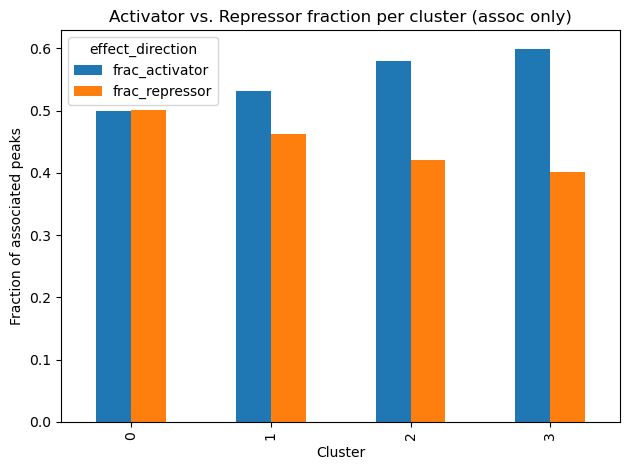

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
counts_filt[['frac_activator','frac_repressor']].plot(
    kind='bar', ax=ax
)
ax.set_xlabel("Cluster")
ax.set_ylabel("Fraction of associated peaks")
ax.set_title("Activator vs. Repressor fraction per cluster (assoc only)")
plt.tight_layout()
plt.show()


Cluster 0 is perfectly balanced, suggesting it contains elements with roughly equal activating and repressing associations.
Cluster 1 starts to lean activator (53 % vs. 47 %).
Cluster 2 is more activator-rich (58 % vs. 42 %).
Cluster 3 is the most skewed toward activators (60 % vs. 40 %).

In [17]:
import umap               
import numpy as np

# 1a) Build the feature matrix: accessibility across your chosen cell types
X = atac2[cell_types].values

# 1b) Fit UMAP to reduce to 2 dimensions
reducer = umap.UMAP(n_components=2, random_state=42)
emb = reducer.fit_transform(X)

# 1c) Add the embedding coordinates back to your DataFrame
atac2['UMAP1'] = emb[:,0]
atac2['UMAP2'] = emb[:,1]

/Users/kaloyan.kostadinov/miniconda3/envs/data_analysis/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kaloyan.kostadinov/miniconda3/envs/data_analysis/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


cluster_assoc
0    90571
3     6540
2     1279
1      203
Name: count, dtype: int64


/Users/kaloyan.kostadinov/miniconda3/envs/data_analysis/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


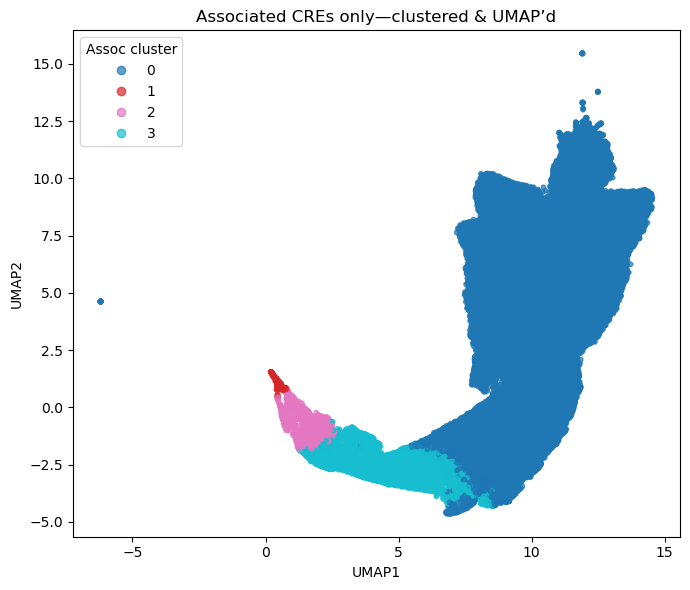

In [18]:
from sklearn.cluster import KMeans
import umap
import matplotlib.pyplot as plt

# 1) Filter to only activator/repressor/neutral peaks
assoc = atac2[atac2['effect_direction']!='no_association'].copy()

# 2) (Re-)cluster assoc peaks on accessibility
X = assoc[cell_types].values
kmeans = KMeans(n_clusters=4, random_state=42)
assoc['cluster_assoc'] = kmeans.fit_predict(X)
print(assoc['cluster_assoc'].value_counts())

# 3) UMAP embedding of assoc peaks (fast if you pre‐PCA first)
#    Or reuse your existing reducer if you want consistency
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
emb = reducer.fit_transform(X)
assoc['UMAP1'], assoc['UMAP2'] = emb[:,0], emb[:,1]

# 4) Plot
fig, ax = plt.subplots(figsize=(7,6))
sc = ax.scatter(
    assoc['UMAP1'], assoc['UMAP2'],
    c=assoc['cluster_assoc'],
    cmap='tab10', s=10, alpha=0.7
)
handles, labels = sc.legend_elements()
ax.legend(handles, labels, title="Assoc cluster")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("Associated CREs only—clustered & UMAP’d")
plt.tight_layout()
plt.show()


In [19]:
# 1) Tabulate counts per assoc-cluster & effect_direction
counts_assoc = (
    assoc
    .groupby(['cluster_assoc','effect_direction'])
    .size()
    .unstack(fill_value=0)
)

# 2) Compute fractions
counts_assoc['total'] = counts_assoc.sum(axis=1)
counts_assoc['frac_act'] = counts_assoc['activator'] / counts_assoc['total']
counts_assoc['frac_rep'] = counts_assoc['repressor'] / counts_assoc['total']

print(counts_assoc[['activator','repressor','frac_act','frac_rep']])


effect_direction  activator  repressor  frac_act  frac_rep
cluster_assoc                                             
0                     45224      45347  0.499321  0.500679
1                       108         94  0.532020  0.463054
2                       741        538  0.579359  0.420641
3                      3917       2623  0.598930  0.401070


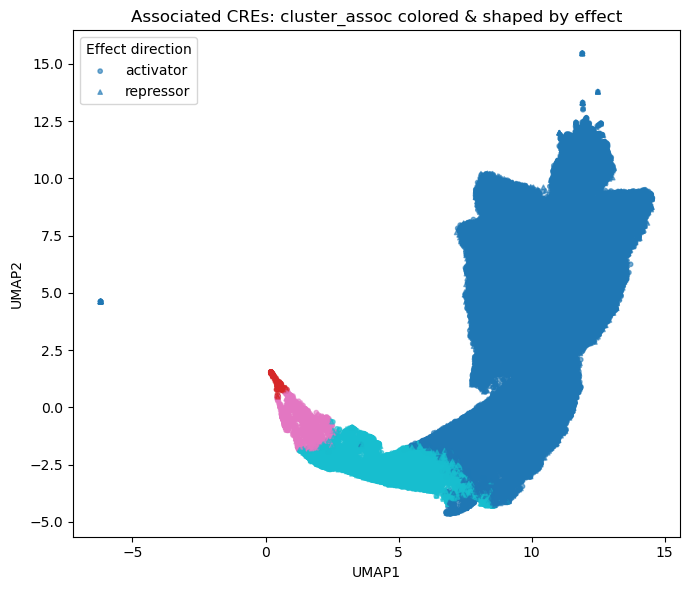

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,6))
for direction, marker in [('activator','o'), ('repressor','^')]:
    sub = assoc[assoc['effect_direction']==direction]
    ax.scatter(sub['UMAP1'], sub['UMAP2'],
               c=sub['cluster_assoc'], cmap='tab10',
               marker=marker, s=10, alpha=0.6, label=direction)
ax.legend(title="Effect direction")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("Associated CREs: cluster_assoc colored & shaped by effect")
plt.tight_layout()
plt.show()


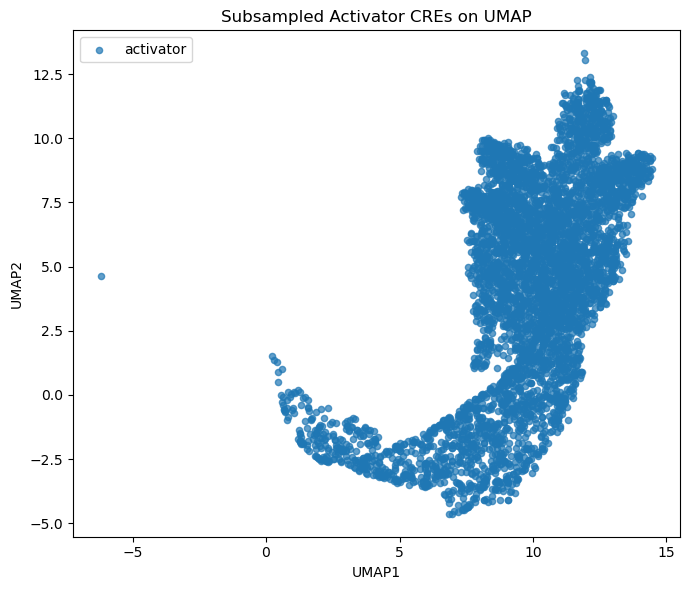

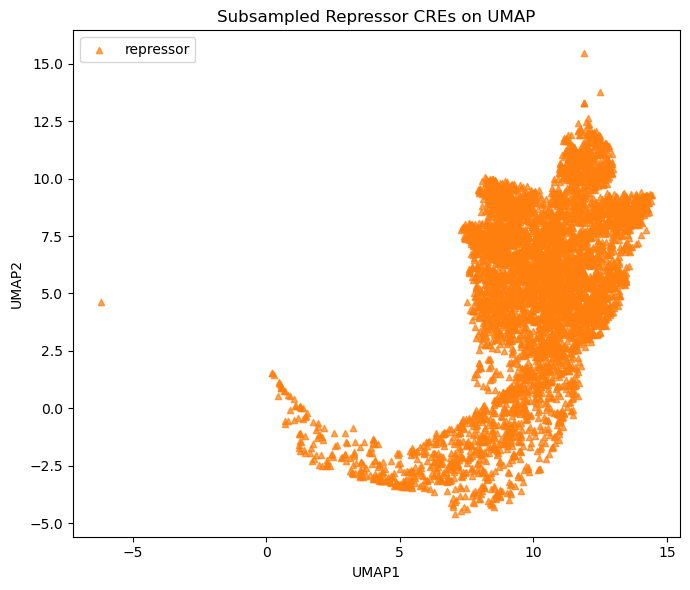

In [21]:
import matplotlib.pyplot as plt

# Number to subsample for clarity
n = 5000

# Subsample activators and repressors
act = assoc[assoc['effect_direction']=='activator'].sample(n, random_state=42)
rep = assoc[assoc['effect_direction']=='repressor'].sample(n, random_state=42)

# --- Plot only Activators ---
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(
    act['UMAP1'], act['UMAP2'],
    marker='o', s=20, alpha=0.7,
    label='activator',
    color='tab:blue'
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("Subsampled Activator CREs on UMAP")
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot only Repressors ---
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(
    rep['UMAP1'], rep['UMAP2'],
    marker='^', s=20, alpha=0.7,
    label='repressor',
    color='tab:orange'
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("Subsampled Repressor CREs on UMAP")
ax.legend()
plt.tight_layout()
plt.show()


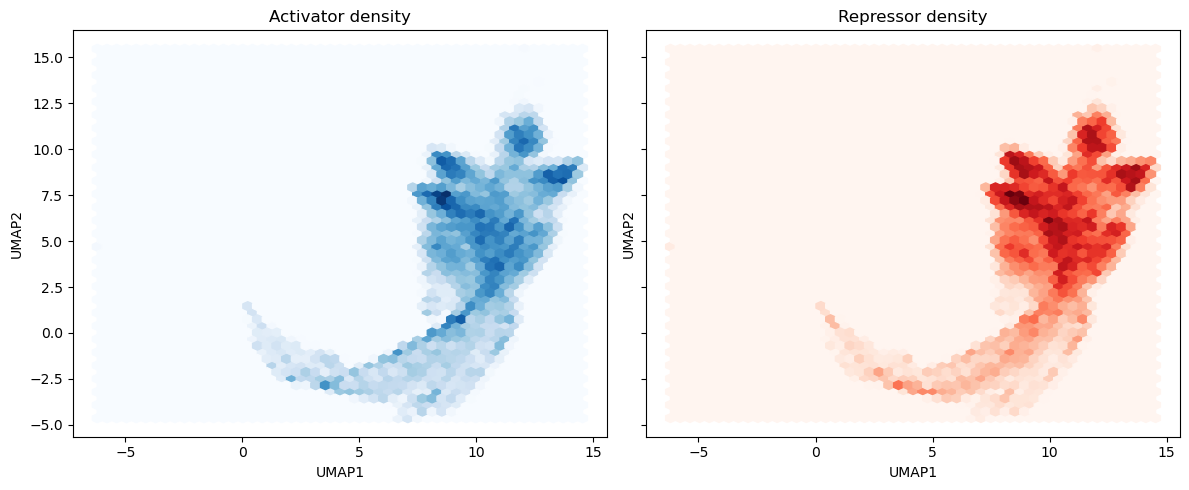

In [22]:
fig, axes = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True)

axes[0].hexbin(
    assoc.query("effect_direction=='activator'")['UMAP1'],
    assoc.query("effect_direction=='activator'")['UMAP2'],
    gridsize=50, cmap='Blues'
)
axes[0].set_title("Activator density")

axes[1].hexbin(
    assoc.query("effect_direction=='repressor'")['UMAP1'],
    assoc.query("effect_direction=='repressor'")['UMAP2'],
    gridsize=50, cmap='Reds'
)
axes[1].set_title("Repressor density")

for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
plt.tight_layout()


In [26]:
import plotly.graph_objects as go

# 1) Build the flow table using the correct cluster column
flow = assoc.groupby(['cluster_assoc', 'effect_direction']) \
            .size() \
            .reset_index(name='count')

# 2) Define node labels: one per assoc-cluster, then one per effect
cluster_ids   = sorted(assoc['cluster_assoc'].unique())
effect_labels = ['activator','repressor','neutral']
labels        = [f"C{c}" for c in cluster_ids] + effect_labels

# 3) Map each cluster and each effect to a node index
cluster_to_idx = {c:i for i,c in enumerate(cluster_ids)}
effect_to_idx  = {e:len(cluster_ids)+j for j,e in enumerate(effect_labels)}

# 4) Build source/target/value arrays
sources = flow['cluster_assoc'].map(cluster_to_idx)
targets = flow['effect_direction'].map(effect_to_idx)
values  = flow['count']

# 5) Plot
fig = go.Figure(go.Sankey(
    node = dict(label=labels),
    link = dict(source=sources, target=targets, value=values)
))
fig.update_layout(
    title_text="CRE cluster (assoc-only) → activator/repressor/neutral flow",
    font_size=10
)
fig.show()


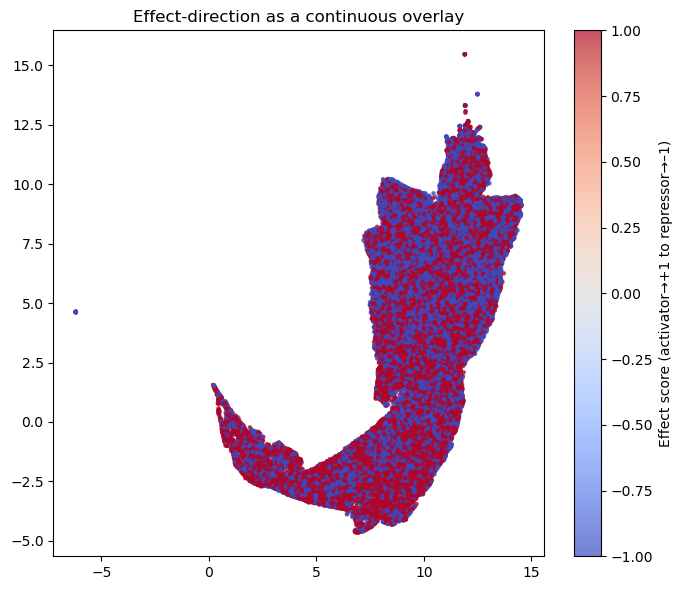

In [28]:
assoc['effect_score'] = assoc['effect_direction'].map({'activator':1,'repressor':-1,'neutral':0})
plt.figure(figsize=(7,6))
plt.scatter(
    assoc['UMAP1'], assoc['UMAP2'],
    c=assoc['effect_score'], cmap='coolwarm',
    s=5, alpha=0.7
)
plt.colorbar(label="Effect score (activator→+1 to repressor→–1)")
plt.title("Effect-direction as a continuous overlay")
plt.tight_layout()


New clusters (with effect):
cluster_feat
0    90720
1     6441
2      184
3     1248
Name: count, dtype: int64

Old vs. New cluster cross-tabulation:
new_cluster      0     1    2     3
old_cluster                        
0            90571     0    0     0
1                0     0  184    19
2                0    50    0  1229
3              149  6391    0     0


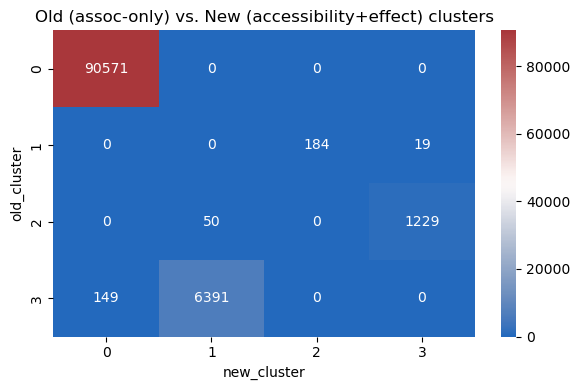

/Users/kaloyan.kostadinov/miniconda3/envs/data_analysis/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



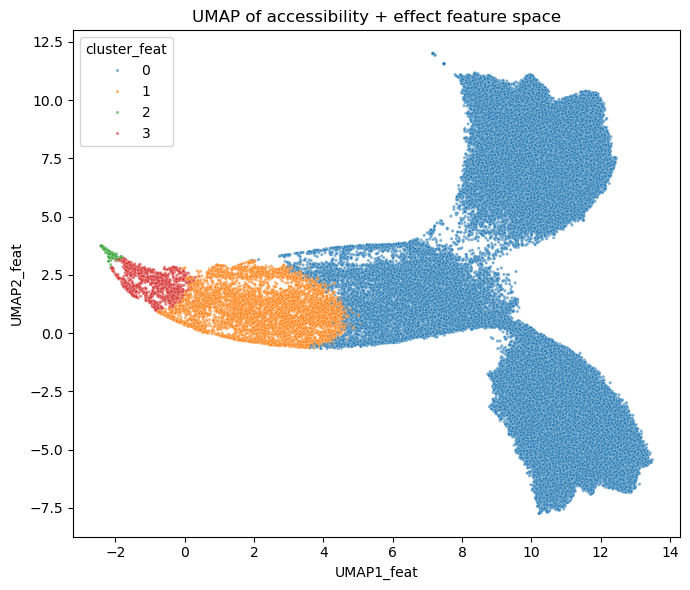

In [29]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Encode effect_direction numerically
assoc['effect_num'] = assoc['effect_direction'].map({
    'activator':  1,
    'repressor': -1,
    'neutral':    0
})

# 2) Build the feature matrix: accessibility + effect_num
X_acc = assoc[cell_types].values
X_feat = np.hstack([X_acc, assoc[['effect_num']].values])

# 3) Re-cluster in 11-D
kmeans_feat = KMeans(n_clusters=4, random_state=42)
assoc['cluster_feat'] = kmeans_feat.fit_predict(X_feat)

# 4) How big are the new clusters?
print("New clusters (with effect):")
print(assoc['cluster_feat'].value_counts().sort_index())

# 5) Compare old vs. new with a confusion matrix
ct = pd.crosstab(
    assoc['cluster_assoc'],
    assoc['cluster_feat'],
    rownames=['old_cluster'],
    colnames=['new_cluster']
)
print("\nOld vs. New cluster cross-tabulation:")
print(ct)

# 6) Heatmap of the contingency table
plt.figure(figsize=(6,4))
sns.heatmap(ct, annot=True, fmt='d', cmap='vlag')
plt.title("Old (assoc-only) vs. New (accessibility+effect) clusters")
plt.tight_layout()
plt.show()

# 7) (Optional) 2D embedding of the new 11-D space to visualize
reducer2 = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
emb2 = reducer2.fit_transform(X_feat)
assoc['UMAP1_feat'], assoc['UMAP2_feat'] = emb2[:,0], emb2[:,1]

plt.figure(figsize=(7,6))
sns.scatterplot(
    x='UMAP1_feat', y='UMAP2_feat',
    hue='cluster_feat',
    palette='tab10',
    data=assoc, s=5, alpha=0.6
)
plt.title("UMAP of accessibility + effect feature space")
plt.tight_layout()
plt.show()


In [30]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# 1) Choose number of bins
nx, ny = 20, 20

# 2) Compute bin indices for each point
x_edges = np.linspace(assoc['UMAP1'].min(), assoc['UMAP1'].max(), nx+1)
y_edges = np.linspace(assoc['UMAP2'].min(), assoc['UMAP2'].max(), ny+1)

assoc['bin_x'] = np.searchsorted(x_edges, assoc['UMAP1'], side='right') - 1
assoc['bin_y'] = np.searchsorted(y_edges, assoc['UMAP2'], side='right') - 1

# 3) Drop any points on the far edge
assoc = assoc.query("0 <= bin_x < @nx and 0 <= bin_y < @ny")

# 4) Aggregate counts per tile and effect
tile_counts = (
    assoc
    .groupby(['bin_x','bin_y','effect_direction'])
    .size()
    .unstack(fill_value=0)
    [['activator','repressor']]  # ignore neutral for now
    .stack()                     # produce a table of shape (nx*ny, 2)
    .unstack(level=2)
)

# 5) χ² test across the whole grid
chi2, p, dof, expected = chi2_contingency(tile_counts.fillna(0))
print(f"χ² = {chi2:.1f}, p = {p:.3e}, dof = {dof}")


χ² = 1627.1, p = 1.407e-263, dof = 118


In [31]:
# e.g. head = top-right quadrant, tail = long lower arc
head_mask = (
    (assoc['UMAP1'] > assoc['UMAP1'].quantile(0.75)) &
    (assoc['UMAP2'] > assoc['UMAP2'].quantile(0.75))
)
tail_mask = (
    (assoc['UMAP1'] < assoc['UMAP1'].quantile(0.50)) &
    (assoc['UMAP2'] < assoc['UMAP2'].quantile(0.25))
)

assoc['region'] = np.where(head_mask, 'head',
                  np.where(tail_mask, 'tail', 'other'))


/var/folders/vh/rffjtjt916gdtb214wntxwb80000gn/T/ipykernel_42621/327771159.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [32]:
# assume all_assoc_df has ['ocr_id','distance'] and assoc has 'ImmGenATAC1219.peakID'
annot = assoc.merge(
    all_assoc_df[['ocr_id','distance','gene']],
    left_on='ImmGenATAC1219.peakID', right_on='ocr_id', how='left'
)


In [33]:
print(
    annot
    .groupby('region')['distance']
    .agg(['count','mean','median','std'])
)


        count         mean  median            std
region                                           
head    12597 -3305.152020  -992.0  106257.723396
other   65557 -3310.867947  -237.0   95619.935148
tail    20437 -3147.389636   -33.0   75671.963049


In [34]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
from sklearn.metrics import adjusted_rand_score

# -----------------------------------------------------------------------------
# 1) Compute fractions in the accessibility‐only clusters (cluster_assoc)
# -----------------------------------------------------------------------------
counts_assoc = (
    assoc
    .groupby(['cluster_assoc','effect_direction'])
    .size()
    .unstack(fill_value=0)
)
counts_assoc['total']      = counts_assoc.sum(axis=1)
counts_assoc['frac_act']   = counts_assoc['activator'] / counts_assoc['total']
counts_assoc['frac_rep']   = counts_assoc['repressor']  / counts_assoc['total']

print("Accessibility-only clusters (assoc) fractions:")
print(counts_assoc[['frac_act','frac_rep']], "\n")

# -----------------------------------------------------------------------------
# 2) Compute fractions in the accessibility+effect clusters (cluster_feat)
# -----------------------------------------------------------------------------
counts_feat = (
    assoc
    .groupby(['cluster_feat','effect_direction'])
    .size()
    .unstack(fill_value=0)
)
counts_feat['total']     = counts_feat.sum(axis=1)
counts_feat['frac_act']  = counts_feat['activator'] / counts_feat['total']
counts_feat['frac_rep']  = counts_feat['repressor']  / counts_feat['total']

print("Accessibility+effect clusters (feat) fractions:")
print(counts_feat[['frac_act','frac_rep']], "\n")

# -----------------------------------------------------------------------------
# 3) Statistical test on assoc-only clusters: Chi-square + Fisher’s per cluster
# -----------------------------------------------------------------------------
cont = counts_assoc[['activator','repressor']]

chi2, p, dof, expected = chi2_contingency(cont)
print(f"Chi-square on assoc-only clusters: χ²={chi2:.2f}, p={p:.3e}, dof={dof}\n")

print("Fisher’s exact per assoc-only cluster:")
for cl in cont.index:
    a = cont.loc[cl, 'activator']
    b = cont.loc[cl, 'repressor']
    a_out = cont['activator'].sum() - a
    b_out = cont['repressor'].sum()  - b
    odds, pval = fisher_exact([[a, b], [a_out, b_out]])
    print(f" Cluster {cl}: odds_ratio={odds:.2f}, p={pval:.3e}")
print()

# -----------------------------------------------------------------------------
# 4) Adjusted Rand Index between old vs. new clusterings
# -----------------------------------------------------------------------------
ari = adjusted_rand_score(assoc['cluster_assoc'], assoc['cluster_feat'])
print(f"Adjusted Rand Index (assoc vs. feat): {ari:.3f}\n")

# -----------------------------------------------------------------------------
# 5) Effect-size: change in activator/repressor fraction per cluster
# -----------------------------------------------------------------------------
merged = counts_assoc[['frac_act','frac_rep']].join(
    counts_feat[['frac_act','frac_rep']],
    lsuffix='_assoc',
    rsuffix='_feat'
)
merged['delta_frac_act'] = merged['frac_act_feat'] - merged['frac_act_assoc']
merged['delta_frac_rep'] = merged['frac_rep_feat'] - merged['frac_rep_assoc']

print("Change in fractions (feat minus assoc):")
print(merged[['delta_frac_act','delta_frac_rep']])


Accessibility-only clusters (assoc) fractions:
effect_direction  frac_act  frac_rep
cluster_assoc                       
0                 0.499321  0.500679
1                 0.532020  0.463054
2                 0.579359  0.420641
3                 0.598930  0.401070 

Accessibility+effect clusters (feat) fractions:
effect_direction  frac_act  frac_rep
cluster_feat                        
0                 0.499405  0.500595
1                 0.599596  0.400404
2                 0.543478  0.451087
3                 0.578526  0.421474 

Chi-square on assoc-only clusters: χ²=269.90, p=3.245e-58, dof=3

Fisher’s exact per assoc-only cluster:
 Cluster 0: odds_ratio=0.68, p=5.395e-60
 Cluster 1: odds_ratio=1.12, p=4.393e-01
 Cluster 2: odds_ratio=1.34, p=1.845e-07
 Cluster 3: odds_ratio=1.49, p=1.119e-53

Adjusted Rand Index (assoc vs. feat): 0.988

Change in fractions (feat minus assoc):
effect_direction  delta_frac_act  delta_frac_rep
cluster_assoc                                   
0   